In [1]:
# %pip install yfinance

In [2]:
# %pip install matplotlib

Backtesting QQQ from 2014-11-30 to 2025-11-30...


C:\Users\SuperGan\AppData\Local\Temp\ipykernel_32396\3573584903.py:126: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=download_start, end=end_date)
[*********************100%***********************]  1 of 1 completed
C:\Users\SuperGan\AppData\Local\Temp\ipykernel_32396\3573584903.py:129: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy_data = yf.download('SPY', start=download_start, end=end_date, progress=False)

C:\Users\SuperGan\AppData\Local\Temp\ipykernel_32396\3573584903.py:129: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy_data = yf.download('SPY', start=download_start, end=end_date, progress=False)


Saved trade log to trade_log.csv (312 rows). Showing first 20 rows:


,date,side,price,amount,shares_before,shares_after,cash_before,cash_after
0,2015-08-21,sell,94.843460,1.477744e+06,15580.869784,0.000000,0.000000e+00,1.477744e+06
1,2015-08-24,buy,91.194199,0.000000e+00,0.000000,0.000000,1.477744e+06,1.477744e+06
2,2015-08-25,buy,90.851524,0.000000e+00,0.000000,0.000000,1.477744e+06,1.477744e+06
3,2015-09-11,buy,97.779518,1.477744e+06,0.000000,15113.017836,1.477744e+06,0.000000e+00
4,2015-09-14,sell,97.483162,1.473265e+06,15113.017836,0.000000,0.000000e+00,1.473265e+06
5,2015-09-15,buy,98.631615,1.473265e+06,0.000000,14937.043965,1.473265e+06,0.000000e+00
6,2015-09-22,sell,96.652580,1.443704e+06,14937.043965,0.000000,0.000000e+00,1.443704e+06
7,2015-09-29,buy,92.353806,0.000000e+00,0.000000,0.000000,1.443704e+06,1.443704e+06
8,2015-10-05,buy,97.952408,1.443704e+06,0.000000,14738.829525,1.443704e+06,0.000000e+00
9,2015-10-06,sell,97.488182,1.436862e+06,14738.829525,0.000000,0.000000e+00,1.436862e+06


--- QQQ Performance ---
Period: 2014-11-30 to 2025-11-30
EMA window: 200 days
Strategy CAGR: 13.60%
Buy and Hold CAGR: 18.45%
Strategy Max Drawdown: -24.92%
Buy and Hold Max Drawdown: -35.12%
Initial Capital: $1,500,000
Final Strategy Portfolio Value: $6,093,149.84
Final Buy & Hold Portfolio Value: $9,648,453.61




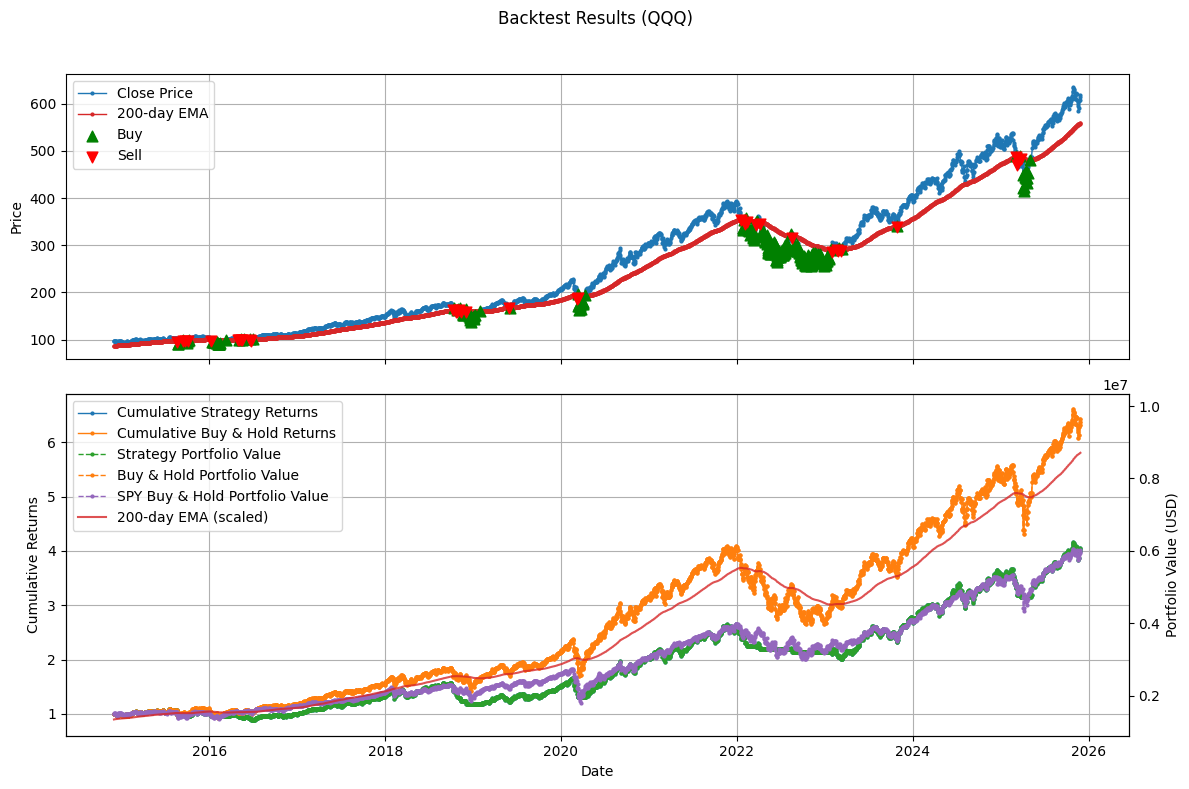

In [8]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# List of tickers to backtest (single ticker recommended for quick runs)
# tickers = ['SPY']
# tickers = ['ASHR']
tickers = ['QQQ']

# Input date range as strings in 'YYYY-MM-DD' format (change these as needed)
start_date_str = '2014-11-30'
end_date_str = '2025-11-30'

# Parse input dates
start_date = pd.to_datetime(start_date_str)
end_date = pd.to_datetime(end_date_str)

# EMA window and buy thresholds (we will use EMA_prev for signals)
ema_window = 200
# thresholds are relative to EMA_prev
threshold_5pct = 0.95  # 5% below
buy_percent_5pt = 0
threshold_10pct = 0.80 # 10% below
buy_percent_10pt = 0

# Initial portfolio capital
initial_capital = 1_500_000


def calculate_max_drawdown(cumulative_returns):
    """
    Calculate the maximum drawdown from a cumulative returns series.
    """
    running_max = cumulative_returns.expanding().max()
    drawdown = (cumulative_returns - running_max) / running_max
    return drawdown.min()


def plot_results(df, start=None, end=None, title_suffix=''):
    """
    Standalone plotting function.
    - `df` should contain the columns:
      'Close', 'EMA' (optional), 'EMA_Scaled' (optional),
      'Cumulative_Strategy_Returns', 'Cumulative_Buy_and_Hold_Returns',
      'Strategy_Portfolio_Value', 'Buy_and_Hold_Portfolio_Value',
      'Trade' and optionally 'Trade2' for days with two actions.
    - `start` / `end` are optional date strings (e.g. '2020-01-01') or Timestamps.
    """
    plot_df = df.copy()
    if start is not None or end is not None:
        plot_df = plot_df.loc[start:end]

    fig, (ax0, ax1) = plt.subplots(2, 1, sharex=True, figsize=(12, 8), gridspec_kw={'height_ratios': [1, 1.2]})

    # Top: Price and EMA (raw price scale)
    if 'Close' in plot_df.columns:
        ax0.plot(plot_df.index, plot_df['Close'], label='Close Price', color='tab:blue', marker='o', markersize=2, linewidth=1)
    if 'EMA' in plot_df.columns:
        ax0.plot(plot_df.index, plot_df['EMA'], label=f'{ema_window}-day EMA', color='tab:red', marker='o', markersize=2, linewidth=1)

    # Plot buy/sell markers if present (support up to two trade markers per day)
    buy_mask = ((plot_df['Trade'] == 'buy') | (plot_df.get('Trade2') == 'buy'))
    sell_mask = ((plot_df['Trade'] == 'sell') | (plot_df.get('Trade2') == 'sell'))
    buys = plot_df[buy_mask]
    sells = plot_df[sell_mask]
    if not buys.empty:
        ax0.scatter(buys.index, buys['Close'], marker='^', color='green', s=60, zorder=5, label='Buy')
    if not sells.empty:
        ax0.scatter(sells.index, sells['Close'], marker='v', color='red', s=60, zorder=5, label='Sell')

    ax0.set_ylabel('Price')
    ax0.legend(loc='upper left')
    ax0.grid(True)

    # Bottom: cumulative returns and portfolio values
    ax1.plot(plot_df.index, plot_df['Cumulative_Strategy_Returns'], label='Cumulative Strategy Returns', marker='o', markersize=2, linewidth=1)
    ax1.plot(plot_df.index, plot_df['Cumulative_Buy_and_Hold_Returns'], label='Cumulative Buy & Hold Returns', marker='o', markersize=2, linewidth=1)
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Cumulative Returns')
    ax1.legend(loc='upper left')
    ax1.grid(True)

    # Right axis: portfolio values and scaled EMA
    ax2 = ax1.twinx()
    if 'Strategy_Portfolio_Value' in plot_df.columns:
        ax2.plot(plot_df.index, plot_df['Strategy_Portfolio_Value'], color='tab:green', linestyle='--', marker='o', markersize=2, linewidth=1, label='Strategy Portfolio Value')
    if 'Buy_and_Hold_Portfolio_Value' in plot_df.columns:
        ax2.plot(plot_df.index, plot_df['Buy_and_Hold_Portfolio_Value'], color='tab:orange', linestyle='--', marker='o', markersize=2, linewidth=1, label='Buy & Hold Portfolio Value')
    if 'SPY_Portfolio_Value' in plot_df.columns:
        ax2.plot(plot_df.index, plot_df['SPY_Portfolio_Value'], color='tab:purple', linestyle='--', marker='o', markersize=2, linewidth=1, label='SPY Buy & Hold Portfolio Value')

    # If EMA_Scaled exists, plot it on same right axis so MA lines up with portfolio values
    if 'EMA_Scaled' in plot_df.columns:
        ax2.plot(plot_df.index, plot_df['EMA_Scaled'], color='tab:red', linestyle='-', alpha=0.8, label=f'{ema_window}-day EMA (scaled)')

    ax2.set_ylabel('Portfolio Value (USD)')

    # combine legends for the bottom plot (returns + portfolio + ema_scaled)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    if title_suffix:
        fig.suptitle(f'Backtest Results {title_suffix}', y=0.98)
    else:
        fig.suptitle('Backtest Results', y=0.98)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


def backtest_ma_strategy(ticker, start_date, end_date, ema_window=ema_window, initial_capital=initial_capital):
    """
    Backtests an EMA sizing strategy with tiered buys and a sell-if-below-EMA rule.

    Modified behavior: buys based on prior-day EMA are allowed even when price < today's EMA.
    To support two actions in a single day (sell then buy), we record up to two trade markers per day.
    
    Also downloads SPY as a benchmark for comparison.
    """
    print(f"Backtesting {ticker} from {start_date.date()} to {end_date.date()}...")

    pad_days = int(ema_window * 3)
    download_start = start_date - pd.DateOffset(days=pad_days)

    data = yf.download(ticker, start=download_start, end=end_date)
    
    # Download SPY as a benchmark
    spy_data = yf.download('SPY', start=download_start, end=end_date, progress=False)
    if isinstance(spy_data.columns, pd.MultiIndex):
        spy_data.columns = spy_data.columns.droplevel(1)
    spy_data.index = pd.to_datetime(spy_data.index)
    if data.empty:
        print("No data downloaded for", ticker)
        return pd.DataFrame()

    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.droplevel(1)

    data.index = pd.to_datetime(data.index)

    data['EMA'] = data['Close'].ewm(span=ema_window, adjust=False).mean()
    data['EMA_prev'] = data['EMA'].shift(1)

    data = data.loc[start_date:end_date].copy()
    if data.empty:
        print('No data in the requested date range after trimming to start/end')
        return pd.DataFrame()

    # Prepare columns
    data['Strategy_Shares'] = 0.0
    data['Strategy_Cash'] = 0.0
    data['Strategy_Portfolio_Value'] = 0.0
    data['Trade'] = None
    data['Trade_Price'] = np.nan
    data['Trade2'] = None
    data['Trade2_Price'] = np.nan

    # Buy & Hold baseline (buy at first valid close with full capital)
    first_close_idx = data['Close'].first_valid_index()
    if first_close_idx is None:
        print("No valid close price for", ticker, "in the requested period")
        return pd.DataFrame()

    first_price = data.loc[first_close_idx, 'Close']
    bh_shares = initial_capital / first_price
    data['Buy_and_Hold_Portfolio_Value'] = bh_shares * data['Close']
    data['Cumulative_Buy_and_Hold_Returns'] = data['Buy_and_Hold_Portfolio_Value'] / initial_capital

    # SPY benchmark: compute buy-and-hold for SPY using same initial capital and dates
    spy_data = spy_data.loc[start_date:end_date].copy()
    if not spy_data.empty:
        spy_first_idx = spy_data['Close'].first_valid_index()
        if spy_first_idx is not None:
            spy_first_price = spy_data.loc[spy_first_idx, 'Close']
            spy_bh_shares = initial_capital / spy_first_price
            spy_data['SPY_Portfolio_Value'] = spy_bh_shares * spy_data['Close']
            # Merge SPY portfolio into main data DataFrame aligned by date
            data = data.join(spy_data[['SPY_Portfolio_Value']], how='left')
            # Forward fill SPY portfolio value for any missing dates
            data['SPY_Portfolio_Value'].fillna(method='ffill', inplace=True)
        else:
            data['SPY_Portfolio_Value'] = np.nan
    else:
        data['SPY_Portfolio_Value'] = np.nan

    # Also add EMA scaled to portfolio-value scale (for plotting)
    data['EMA_Scaled'] = data['EMA'] * bh_shares

    # Strategy starts fully invested at first close within requested period
    strategy_shares = initial_capital / first_price
    strategy_cash = 0.0

    # transaction log
    trades = []

    # Set initial row at first_close_idx
    data.loc[first_close_idx, 'Strategy_Shares'] = strategy_shares
    data.loc[first_close_idx, 'Strategy_Cash'] = strategy_cash
    data.loc[first_close_idx, 'Strategy_Portfolio_Value'] = strategy_shares * data.loc[first_close_idx, 'Close'] + strategy_cash

    idxs = list(data.index)
    start_pos = idxs.index(first_close_idx)

    for dt in idxs[start_pos+1:]:
        price = data.loc[dt, 'Close']
        ema = data.loc[dt, 'EMA']
        ema_prev = data.loc[dt, 'EMA_prev']

        shares_before = strategy_shares
        cash_before = strategy_cash

        sell_executed = False
        sell_amount = 0.0
        buy_executed = False
        buy_amount = 0.0

        # SELL rule: if price < today's EMA -> sell all (if holding)
        if pd.notna(ema) and price < ema and strategy_shares > 0:
            sell_amount = strategy_shares * price
            strategy_cash += sell_amount
            strategy_shares = 0.0
            sell_executed = True

        # BUY rules using prior-day EMA (ema_prev) when available
        # Note: we allow buys even when price < today's EMA
        if pd.notna(ema_prev) and strategy_cash > 0:
            # Check 5% below first (per your request), then 10%
            # This evaluates the 5% rule before the 10% rule.
            if price <= threshold_5pct * ema_prev:
                # Buy 50% of available cash at 5% below EMA_prev
                buy_amount = strategy_cash * buy_percent_5pt
                strategy_shares += buy_amount / price
                strategy_cash -= buy_amount
                buy_executed = True
            elif price <= threshold_10pct * ema_prev:
                # Buy all remaining cash at 10% below EMA_prev
                buy_amount = strategy_cash * buy_percent_10pt
                strategy_shares += buy_amount / price
                strategy_cash = 0.0
                buy_executed = True
            elif price > ema_prev:
                buy_amount = strategy_cash
                strategy_shares += buy_amount / price
                strategy_cash = 0.0
                buy_executed = True

        # record state
        data.loc[dt, 'Strategy_Shares'] = strategy_shares
        data.loc[dt, 'Strategy_Cash'] = strategy_cash
        data.loc[dt, 'Strategy_Portfolio_Value'] = strategy_shares * price + strategy_cash

        # append trades (support up to two events per day)
        if sell_executed:
            trades.append({
                'date': dt,
                'side': 'sell',
                'price': price,
                'amount': sell_amount,
                'shares_before': shares_before,
                'shares_after': strategy_shares,
                'cash_before': cash_before,
                'cash_after': strategy_cash
            })
            # mark first trade slot as sell unless Trade already used
            if pd.isna(data.loc[dt, 'Trade_Price']) and data.loc[dt, 'Trade'] is None:
                data.loc[dt, 'Trade'] = 'sell'
                data.loc[dt, 'Trade_Price'] = price
            else:
                data.loc[dt, 'Trade2'] = 'sell'
                data.loc[dt, 'Trade2_Price'] = price

        if buy_executed:
            trades.append({
                'date': dt,
                'side': 'buy',
                'price': price,
                'amount': buy_amount,
                'shares_before': shares_before,
                'shares_after': strategy_shares,
                'cash_before': cash_before,
                'cash_after': strategy_cash
            })
            # prefer to label primary Trade as buy if empty, otherwise put in Trade2
            if data.loc[dt, 'Trade'] is None:
                data.loc[dt, 'Trade'] = 'buy'
                data.loc[dt, 'Trade_Price'] = price
            else:
                data.loc[dt, 'Trade2'] = 'buy'
                data.loc[dt, 'Trade2_Price'] = price

    # Forward-fill if needed
    data['Strategy_Shares'].ffill(inplace=True)
    data['Strategy_Cash'].ffill(inplace=True)
    data['Strategy_Portfolio_Value'].ffill(inplace=True)

    # Cumulative returns for strategy
    data['Cumulative_Strategy_Returns'] = data['Strategy_Portfolio_Value'] / initial_capital
    data['Strategy_Returns'] = data['Strategy_Portfolio_Value'].pct_change().fillna(0)

    # Persist trades to CSV and show head
    trades_df = pd.DataFrame(trades)
    if not trades_df.empty:
        trades_df.to_csv('trade_log.csv', index=False)
        print(f"Saved trade log to trade_log.csv ({len(trades_df)} rows). Showing first 20 rows:")
        display(trades_df.head(20))
    else:
        print("No trades executed during the backtest period.")

    # Performance metrics
    valid_start = data['Cumulative_Buy_and_Hold_Returns'].first_valid_index()
    if valid_start is None:
        years = 1
    else:
        years = max((data.index[-1] - valid_start).days / 365.25, 1e-9)

    strategy_cagr = data['Cumulative_Strategy_Returns'].iloc[-1] ** (1/years) - 1
    buy_and_hold_cagr = data['Cumulative_Buy_and_Hold_Returns'].iloc[-1] ** (1/years) - 1
    strategy_max_drawdown = calculate_max_drawdown(data['Cumulative_Strategy_Returns'])
    buy_and_hold_max_drawdown = calculate_max_drawdown(data['Cumulative_Buy_and_Hold_Returns'])

    final_strategy_value = data['Strategy_Portfolio_Value'].iloc[-1]
    final_bh_value = data['Buy_and_Hold_Portfolio_Value'].iloc[-1]

    # Print final performance
    print(f"--- {ticker} Performance ---")
    print(f"Period: {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}")
    print(f"EMA window: {ema_window} days")
    print(f"Strategy CAGR: {strategy_cagr:.2%}")
    print(f"Buy and Hold CAGR: {buy_and_hold_cagr:.2%}")
    print(f"Strategy Max Drawdown: {strategy_max_drawdown:.2%}")
    print(f"Buy and Hold Max Drawdown: {buy_and_hold_max_drawdown:.2%}")
    print(f"Initial Capital: ${initial_capital:,.0f}")
    print(f"Final Strategy Portfolio Value: ${final_strategy_value:,.2f}")
    print(f"Final Buy & Hold Portfolio Value: ${final_bh_value:,.2f}")
    print("\n")

    # Default full-period plot
    plot_results(data, title_suffix=f"({ticker})")

    return data


# Run the backtest for each ticker and collect results in a dict
results = {}
for ticker in tickers:
    results[ticker] = backtest_ma_strategy(ticker, start_date, end_date)


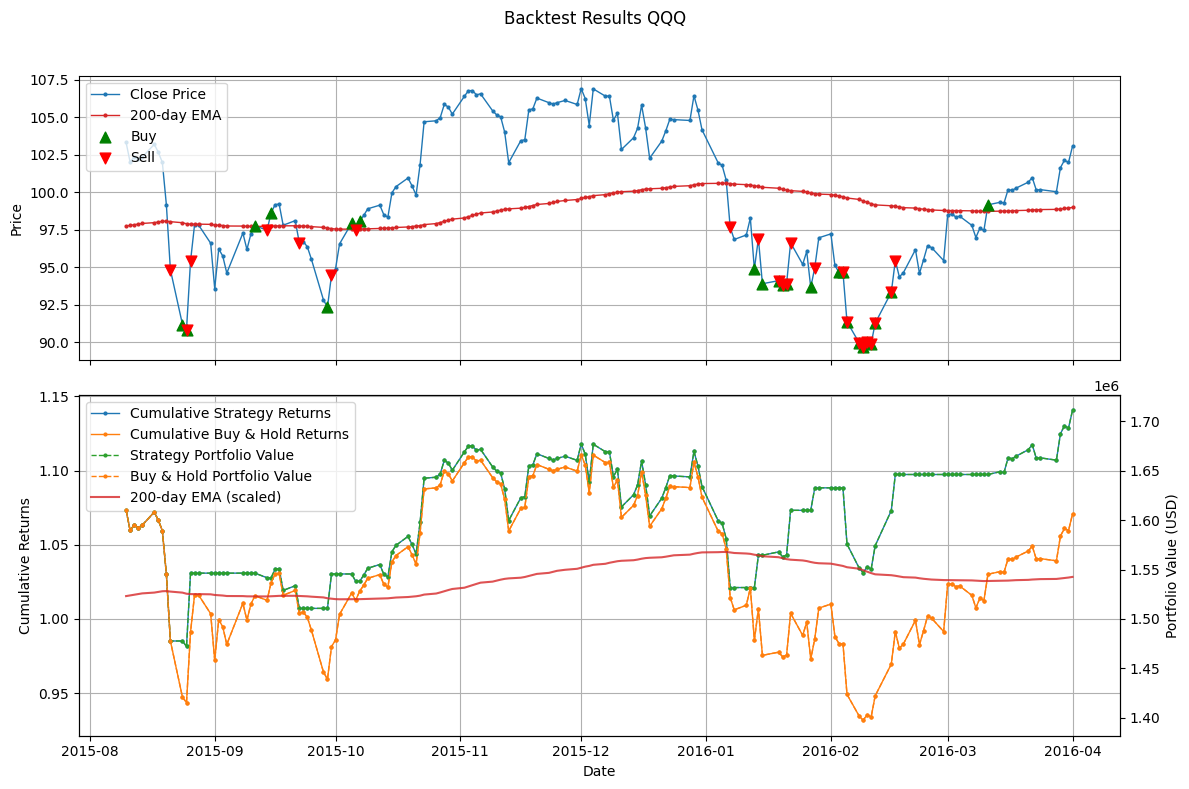

In [4]:
# plot_results(results[ticker], '2015-11-01', '2016-04-30', ticker)
plot_results(results[ticker], '2015-08-10', '2016-04-01', ticker)